In [3]:
mimport os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.image import imread
import requests
matplotlib.rcParams['figure.figsize'] = (16, 9)

Text(0.5, 1.0, 'Grafico de barras de valores singulares')

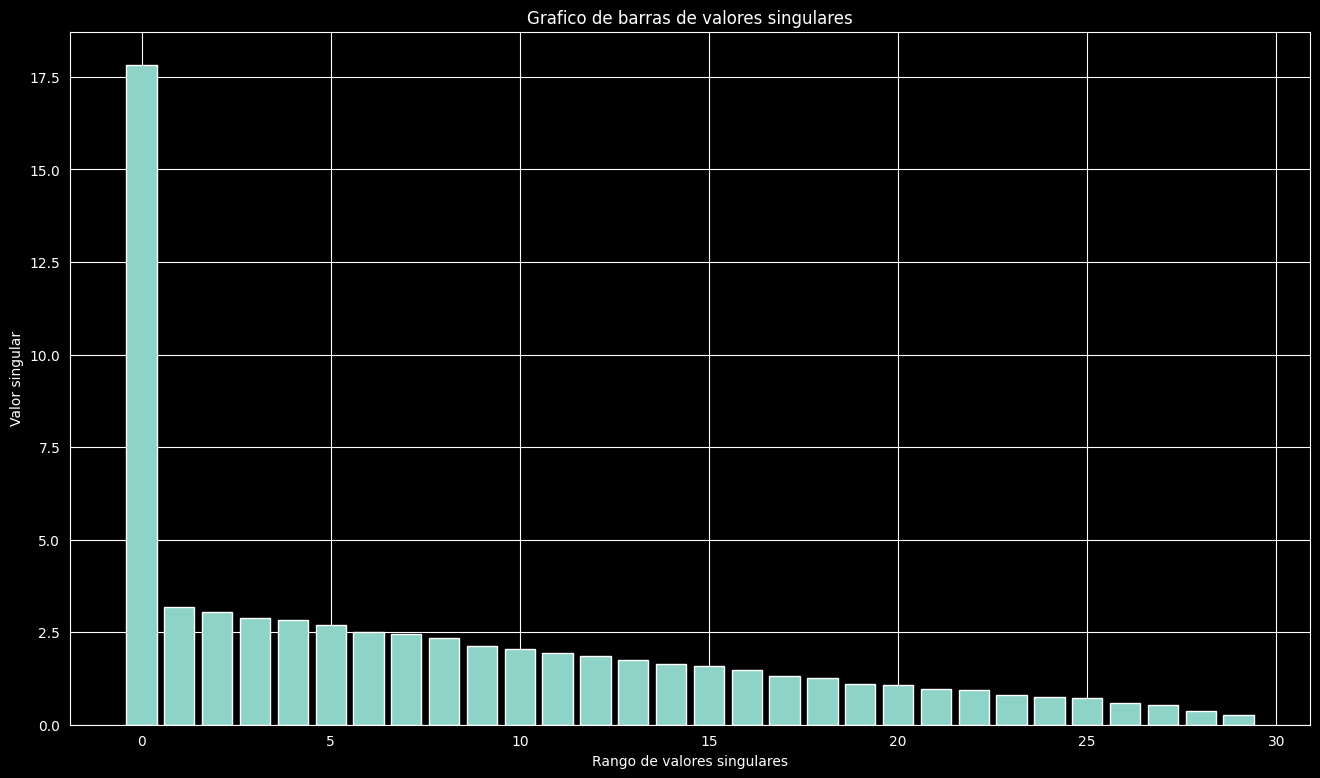

In [4]:
A = tf.random.uniform(shape=[40, 30])
s, U, V = tf.linalg.svd(A)
S = tf.linalg.diag(s)
V_T = tf.transpose(V)
A_svd =U @ S @ V_T
plt.bar(range(len(s)), s)
plt.xlabel("Rango de valores singulares")
plt.ylabel("Valor singular")
plt.title("Grafico de barras de valores singulares")

In [5]:
A_svd = tf.einsum('s, us, vs-> uv', s, U, V)
print("\n reconstructed matrix", A_svd)


 reconstructed matrix tf.Tensor(
[[0.58687085 0.24630179 0.08138969 ... 0.3350087  0.38495955 0.66297406]
 [0.84347814 0.82749796 0.87094903 ... 0.877519   0.8973784  0.5742267 ]
 [0.1786949  0.70660675 0.99826545 ... 0.3637592  0.41630378 0.50860023]
 ...
 [0.16989481 0.23304768 0.04146475 ... 0.98343855 0.50413257 0.8884711 ]
 [0.05363363 0.93611145 0.62198234 ... 0.85883987 0.49699038 0.04204266]
 [0.8025061  0.14953059 0.68013    ... 0.24556926 0.86838627 0.86117005]], shape=(40, 30), dtype=float32)


In [14]:
def rank_r_aprox(s, U, V, r, verbose=False):
    s_r, U_r, V_r = s[..., :r], U[..., :, :r], V[..., :, :r]
    A_r = tf.einsum('...s, ...us, ...vs ->...uv', s_r, U_r, V_r)
    A_r_size = tf.size(U_r) + tf.size(s_r) + tf.size(V_r)
    if verbose:
        print(f"Aproximation size: {A_r_size}")
    return A_r, A_r_size


def viz_approx(A, A_r):
    vmin, vmax = 0, tf.reduce_max(A)
    fig, ax = plt.subplots(1, 3)
    mats = [A, A_r, abs(A - A_r)]
    titles = ['Original A', 'Approximated A_r', 'Error |A - A_r|']
    for i, (mat, title) in enumerate(zip(mats, titles)):
        ax[i].pcolormesh(mat, vmin=vmin, vmax=vmax)
        ax[i].set_title(title)
        ax[i].axis('off')

In [15]:
print(f'Tamaño original de A: {tf.size(A)}')
s, U, V = tf.linalg.svd(A)

Tamaño original de A: 1200


Aproximation size: 1065


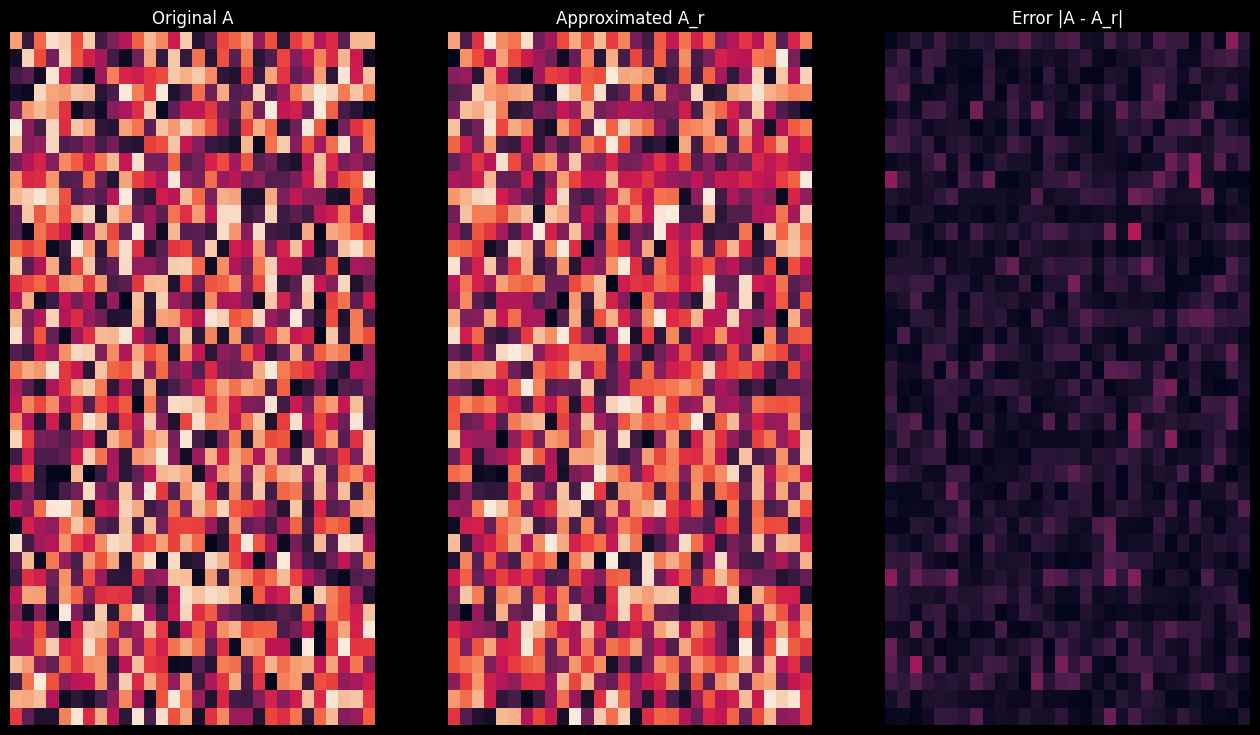

In [16]:
# Aproximación de rango 15
A_15, A_15_SIZE = rank_r_aprox(s, U, V, 15, verbose=True)
viz_approx(A, A_15)

Aproximation size: 213


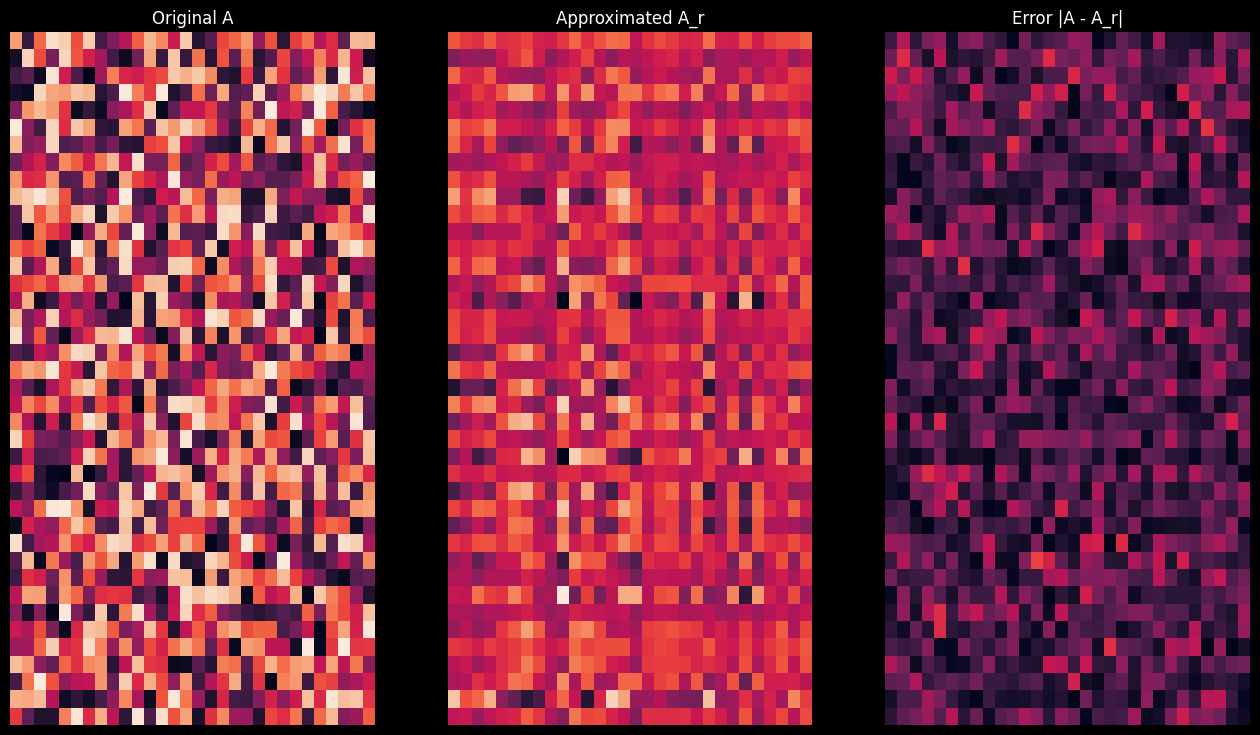

In [17]:
A_3, A_3_size = rank_r_aprox(s, U, V, 3, verbose=True)
viz_approx(A, A_3)

In [19]:
img_link = "https://imagen.research.google/main_gallery_images/a-photo-of-a-corgi-dog-riding-a-bike-in-times-square.jpg"
img_path = requests.get(img_link, stream=True).raw
I = imread(img_path, 0)
print("Input image shape:", I.shape)

Input image shape: (1024, 1024, 3)


In [20]:
def show_img(I):
    img = plt.imshow(I)
    plt.axis('off')
    return

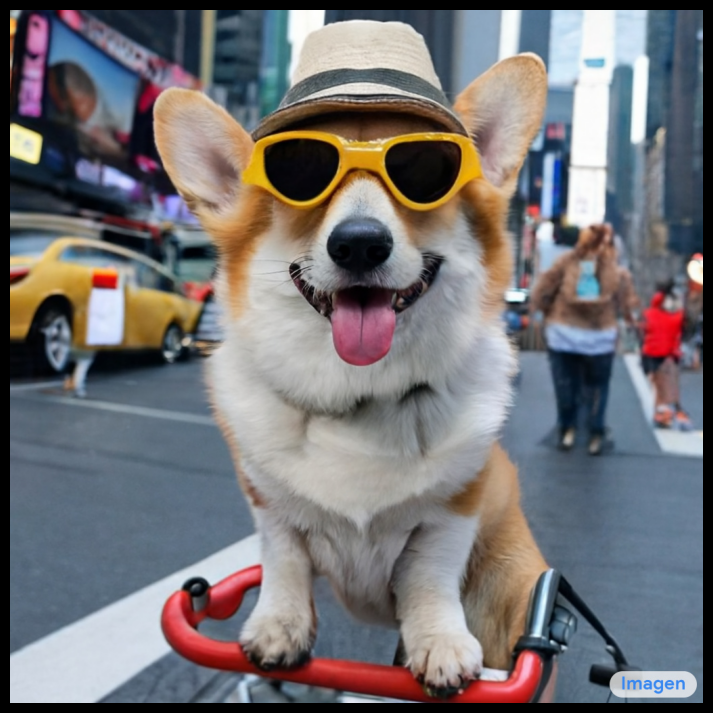

In [21]:
show_img(I)

In [24]:
def compress_image(I, r, verbose=False):
    I_size = tf.size(I)
    print(f'Original image size: {I_size}')
    I = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    I_r, I_r_size = rank_r_aprox(s, U, V, r)
    I_r = tf.transpose(I_r, [1, 2, 0])
    I_r_prop = (I_r_size / I_size)
    if verbose:
        print(f"Number of singular values used in compression: {r}")
        print(f"Compressed image size: {I_r_size}")
        print(f"Proportion of original size: {I_r_prop:.3f}")
        ax_1 = plt.subplot(1, 2, 1)
        show_img(tf.clip_by_value(I_r, 0, 1))
        ax_1.set_title('Approximated image')
        ax_2 = plt.subplot(1, 2, 2)
        show_img(tf.clip_by_value(0.5 + abs(I - I_r), 0., 1.))
        ax_2.set_title('Error')
    return I_r, I_r_prop

Original image size: 3145728
Number of singular values used in compression: 100
Compressed image size: 614700
Proportion of original size: 0.195


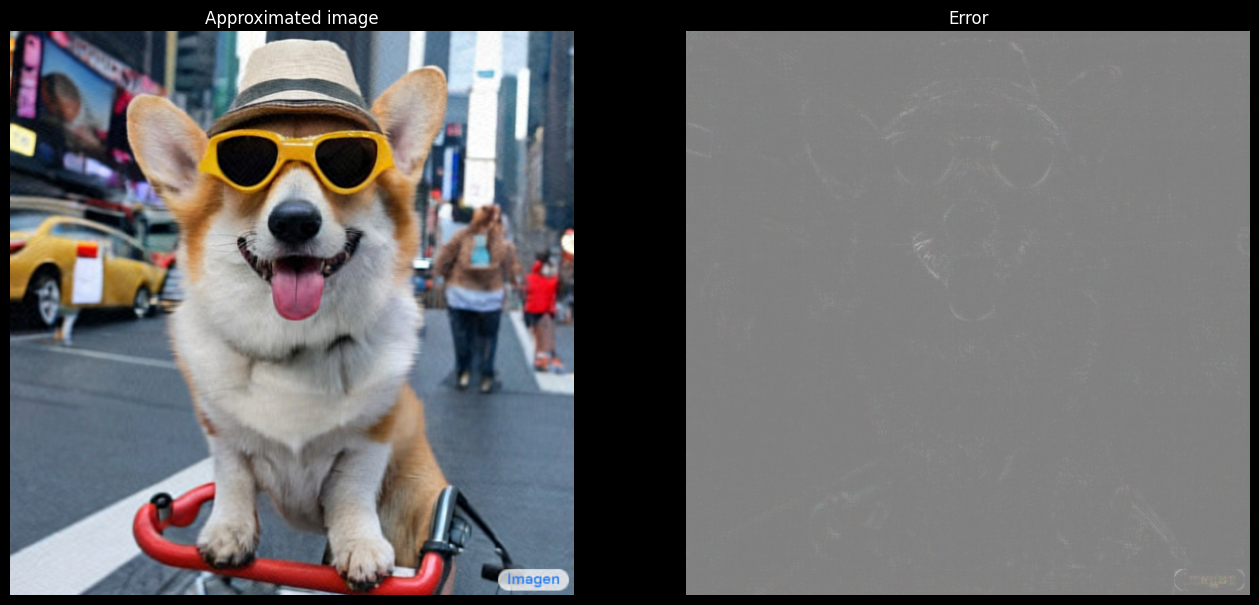

In [25]:
I_100, I_100_prop = compress_image(I, 100, verbose=True)

Original image size: 3145728
Number of singular values used in compression: 50
Compressed image size: 307350
Proportion of original size: 0.098


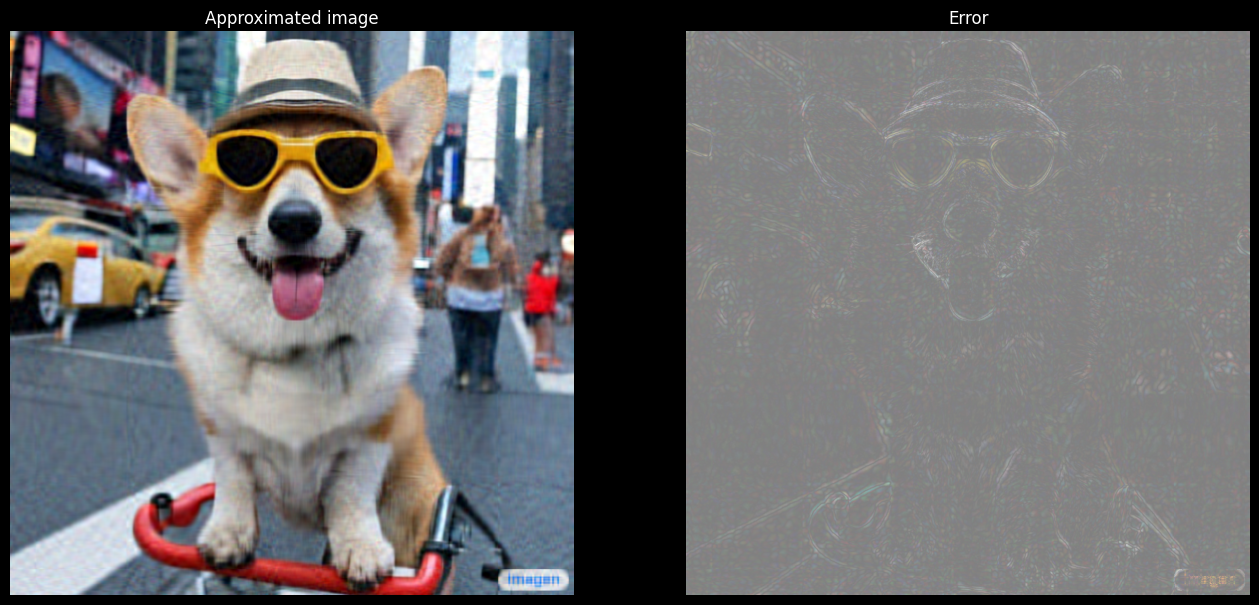

In [26]:
I_50, I_50_prop = compress_image(I, 50, verbose=True)

Original image size: 3145728
Number of singular values used in compression: 10
Compressed image size: 61470
Proportion of original size: 0.020


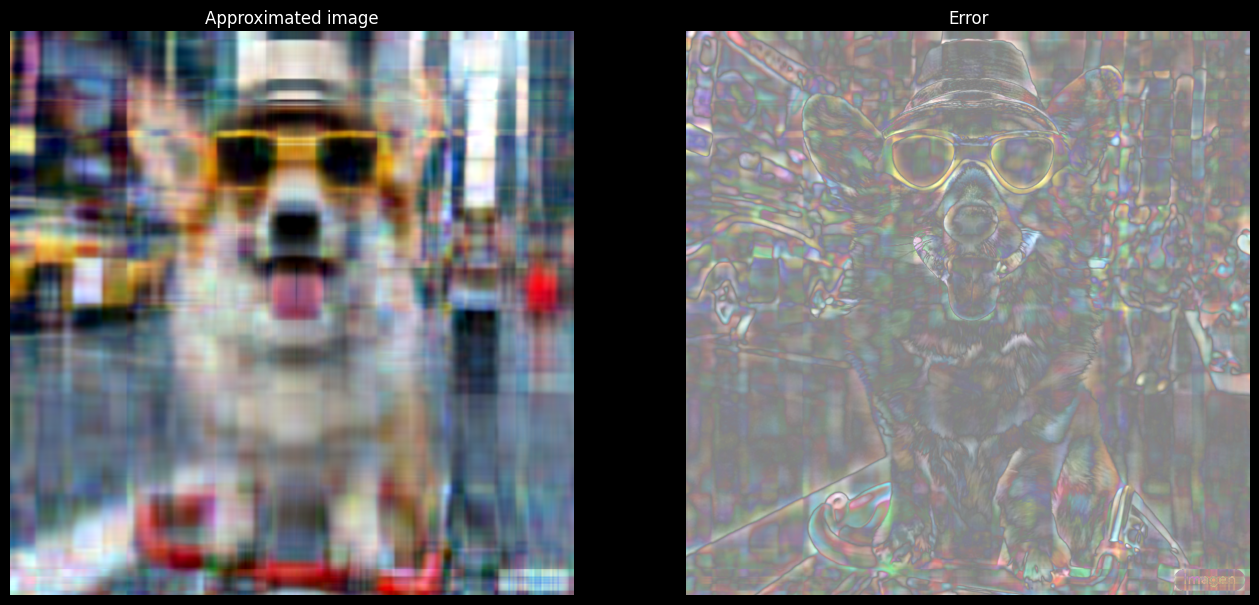

In [28]:
I_10, I_10_prop = compress_image(I, 10, verbose=True)

Text(0.5, 1.0, 'Proportion of original size vs rank')

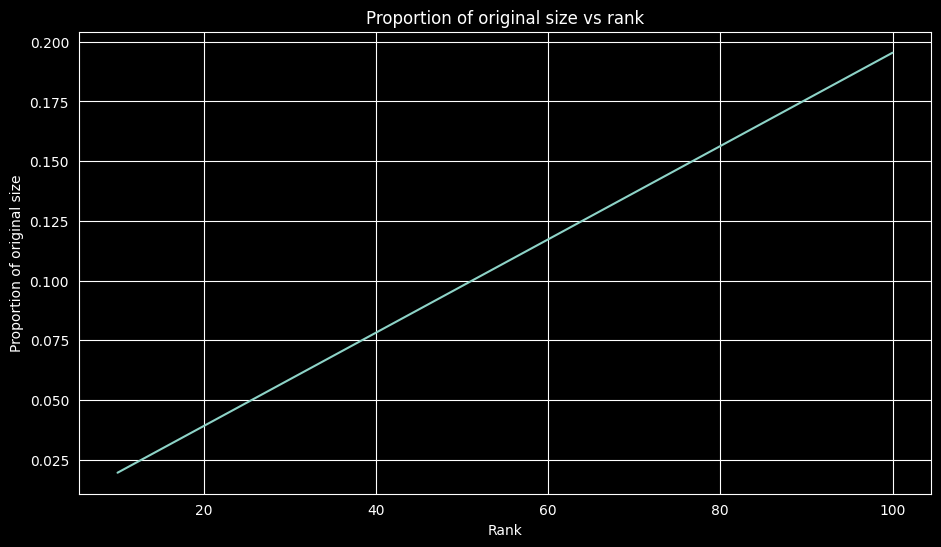

In [29]:
plt.figure(figsize=(11, 6))
plt.plot([100, 50, 10], [I_100_prop, I_50_prop, I_10_prop])
plt.xlabel("Rank")
plt.ylabel("Proportion of original size")
plt.title("Proportion of original size vs rank")

In [30]:
def compress_image_with_factor(I, compression_factor, verbose=False):
    m, n, o = I.shape
    r = int((compression_factor * m * n) / (m + n + 1))
    I_r, I_r_prop = compress_image(I, r, verbose=verbose)
    return I_r

Original image size: 3145728
Number of singular values used in compression: 76
Compressed image size: 467172
Proportion of original size: 0.149


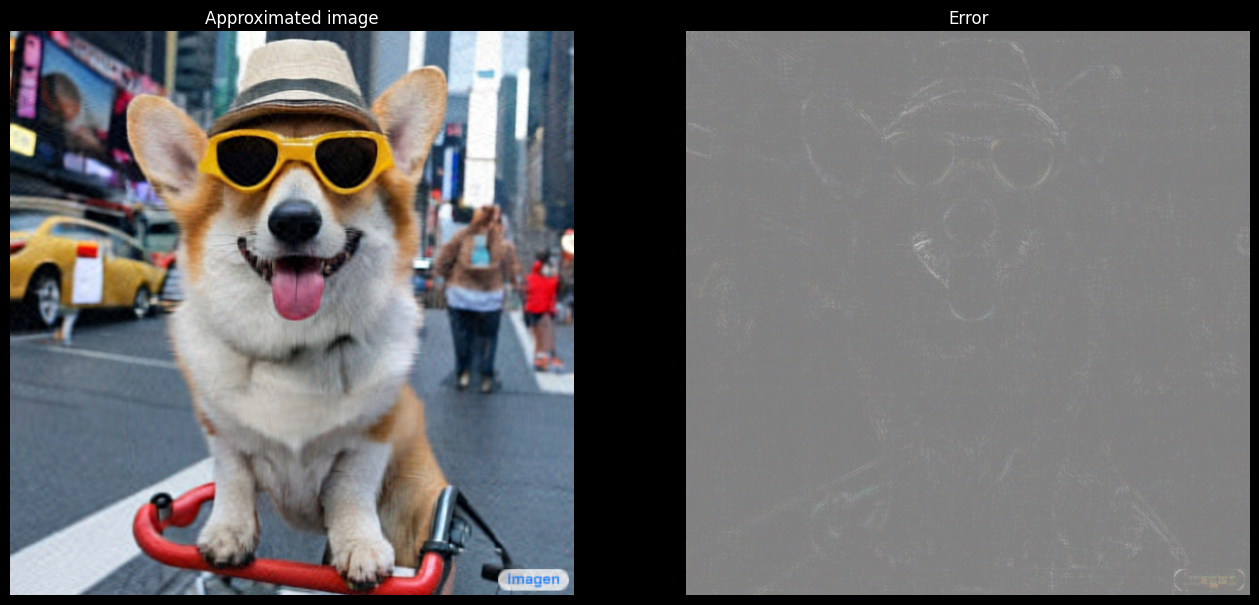

In [31]:
compression_factor = 0.15
I_r_img = compress_image_with_factor(I, compression_factor, verbose=True)

In [32]:
def viz_energy(I):
    I = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    props_rgb = tf.map_fn(lambda x: tf.cumsum(x) / tf.reduce_sum(x), s)
    props_rgb_mean = tf.reduce_mean(props_rgb, axis=0)
    plt.figure(figsize=(11, 6))
    plt.plot(range(len(I)), props_rgb_mean, color='red')
    plt.xlabel("Rank / singular value number")
    plt.ylabel("Cumulative sum of singular values")
    plt.title("RGB-averaged proportion of energy captured by the first r singular values")

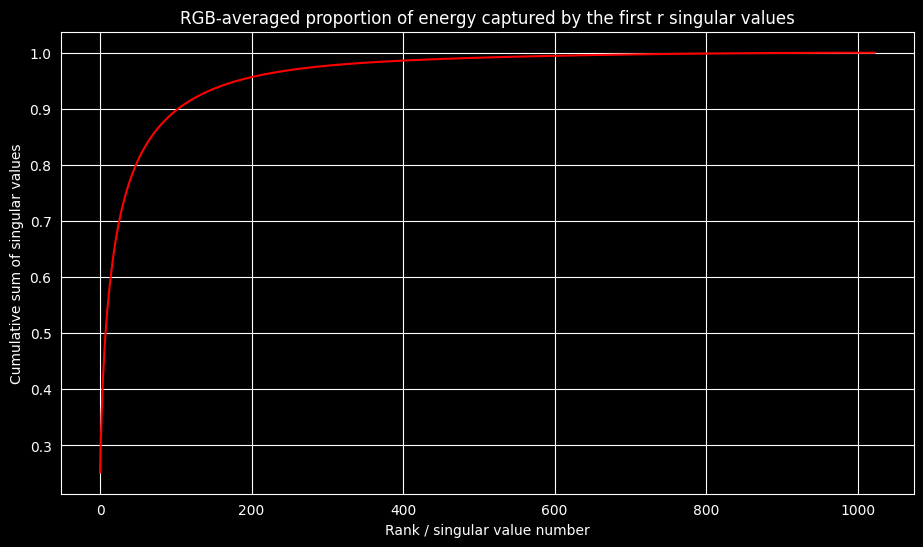

In [33]:
viz_energy(I)

In [34]:
def compress_image_with_energy(I, energy_factor, verbose=False):
    I_rescaled = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I_rescaled, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    props_rgb = tf.map_fn(lambda x: tf.cumsum(x) / tf.reduce_sum(x), s)
    props_rgb_mean = tf.reduce_mean(props_rgb, axis=0)
    r = tf.argmin(tf.abs(props_rgb_mean - energy_factor)) + 1
    actual_ef = props_rgb_mean[r]
    I_r, I_r_prop = compress_image(I, r, verbose=verbose)
    print(f"Proportion of energy captured by the first {r} singular values: {actual_ef:.3f}")
    return I_r

Original image size: 3145728
Number of singular values used in compression: 35
Compressed image size: 215145
Proportion of original size: 0.068
Proportion of energy captured by the first 35 singular values: 0.753


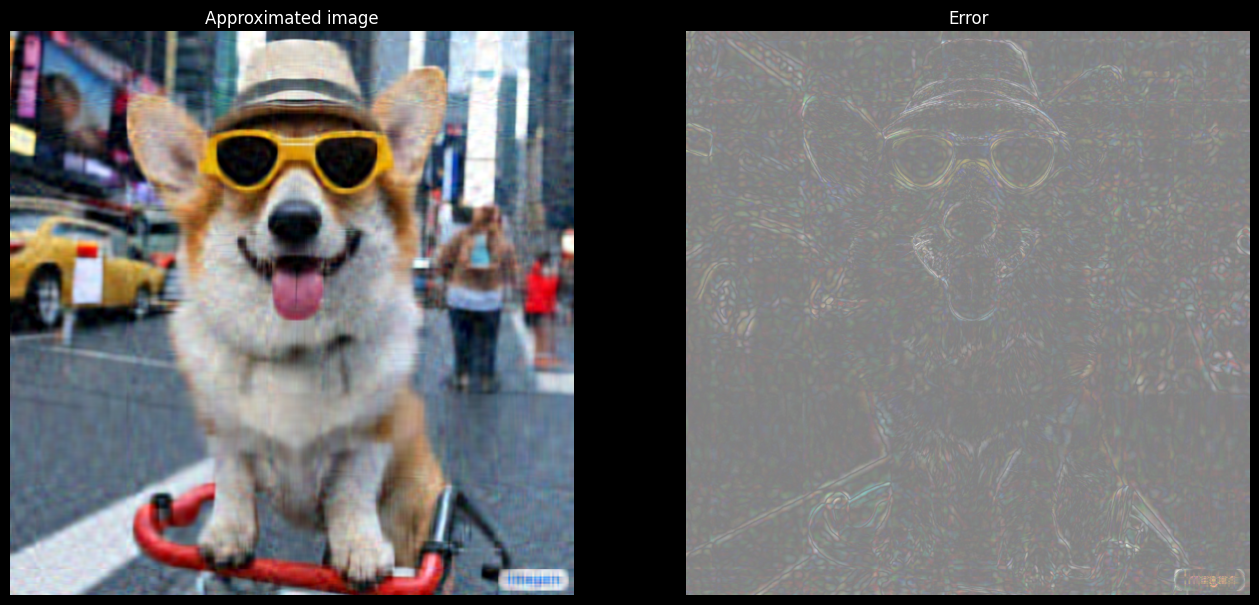

In [35]:
energy_factor = 0.75
I_r_img = compress_image_with_energy(I, energy_factor, verbose=True)

In [36]:
s, U, V = tf.linalg.svd(A)
A_10, A_10_size = rank_r_aprox(s, U, V, 10)
squared_norm = tf.norm(A - A_10)**2
s_squared_sum = tf.reduce_sum(s[10:]**2)
print(f"Squared Frobenius norm: {squared_norm:.3f}")
print(f"Sum of squared singular values left out: {s_squared_sum:.3f}")

Squared Frobenius norm: 31.864
Sum of squared singular values left out: 31.864
